# Double-Well Potential

## Problem Setup

### Potential

$$V(x) = \frac{x^4}{4} - \frac{x^2}{2}$$

### Gradient

$$V'(x) = x^3 - x = x(x^2-1)$$

Stationary points: $V'(x)=0 \Rightarrow x \in \{-1,0,+1\}$.

### Target Boltzmann density

$$\pi_\infty(x) = Z^{-1}\exp\!\left(-\frac{2V(x)}{\sigma^2}\right)$$


## Setup

In [1]:
import numpy as np
import scipy.integrate as sci
import scipy.stats as scs
import matplotlib.pyplot as plt
import time
from math import gamma
from pathlib import Path
from typing import Callable, Tuple

plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

GLOBAL_SEED = 42
rng = np.random.default_rng(GLOBAL_SEED)

OUT = Path('doublewell_output')
OUT.mkdir(exist_ok=True)

In [2]:
def V(x):
    """V(x) = x^4/4 - x^2/2."""
    return x**4 / 4.0 - x**2 / 2.0

def gradV(x):
    """V'(x) = x^3 - x."""
    return x**3 - x

def hessV(x):
    """V''(x) = 3x^2 - 1."""
    return 3.0 * x**2 - 1.0

def log_pi_unnorm(x, sigma):
    """Unnormalized log pi_inf = -2V(x)/sigma^2."""
    return -2.0 * V(x) / sigma**2

def grad_log_pi(x, sigma):
    """grad log pi_inf = -2 V'(x) / sigma^2."""
    return -2.0 * gradV(x) / sigma**2

def gradU(x, sigma):
    """gradU for pi(x) ∝ exp(-2V(x)/sigma^2): gradU = 2 V'(x) / sigma^2."""
    return -grad_log_pi(x, sigma)

### Target reference sampler

In [3]:
class TargetSampler:
    """Numerical inverse-CDF sampler for pi_inf(x) = Z^{-1} exp(-2V(x)/sigma^2).
    
    This is an unavoidable numerical step: the CDF of pi_inf is not elementary.
    """

    def __init__(self, sigma: float, L: float = 4.0, n_grid: int = 80_000):
        self.sigma = sigma
        self.L = L
        self.n_grid = n_grid
        self._build()

    def _build(self):
        xs = np.linspace(-self.L, self.L, self.n_grid)
        log_p = log_pi_unnorm(xs, self.sigma)
        log_p -= log_p.max()  # numerical stability
        p = np.exp(log_p)
        Z_approx = np.trapezoid(p, xs)
        self._p_norm = p / Z_approx
        # CDF by cumulative trapezoid
        dx = xs[1] - xs[0]
        cdf = np.concatenate([[0.0], np.cumsum(0.5*(self._p_norm[:-1]+self._p_norm[1:])*dx)])
        self.tail_mass = 1.0 - cdf[-1]
        self._xs = xs
        self._cdf = cdf

    def sample(self, n: int, rng_: np.random.Generator) -> np.ndarray:
        """Draw n iid samples from pi_inf by inverse-CDF (numerical)."""
        u = rng_.uniform(0.0, self._cdf[-1], size=n)
        return np.interp(u, self._cdf, self._xs)

    def density(self, x) -> np.ndarray:
        """Normalized density at x by grid interpolation."""
        return np.interp(np.asarray(x), self._xs, self._p_norm)

    def diagnostic(self):
        print(f"TargetSampler: L={self.L}, n_grid={self.n_grid}")
        print(f"  tail mass outside [-{self.L},{self.L}]: {self.tail_mass:.2e}")

## 5.3 Metrics

### W2
$$W_2^2(\hat{\mu}_X,\hat{\mu}_Y) = \frac{1}{N}\sum_i(x_{(i)}-y_{(i)})^2 \quad \text{(exact, via sorting)}$$

### MMD²

Kernel: $k(x,y)=\exp(-(x-y)^2/2h^2)$, bandwidth $h$ is an explicit parameter.

$$\widehat{\mathrm{MMD}}^2_b = \frac{1}{N^2}\sum_{i,j}k(x_i,x_j) - \frac{2}{NM}\sum_{i,j}k(x_i,y_j) + \frac{1}{M^2}\sum_{i,j}k(y_i,y_j)$$

### EMC
$$\mathrm{EMC} = -\frac{p_L\log p_L + p_R\log p_R}{\log 2}$$

In [4]:
def _finite(x: np.ndarray) -> np.ndarray:
    """Return only the finite (non-NaN, non-Inf) entries of x."""
    return x[np.isfinite(x)]


def w2_empirical_1d(x: np.ndarray, y: np.ndarray) -> float:
    """Exact empirical 1D W2 via sorting.

    Filters NaN/Inf before sorting, then subsamples to min(|x|,|y|).
    Returns np.nan if either finite sample is empty.
    """
    xf, yf = _finite(x), _finite(y)
    n = min(len(xf), len(yf))
    if n == 0:
        return float('nan')
    return float(np.sqrt(np.mean((np.sort(xf[:n]) - np.sort(yf[:n]))**2)))


def mmd_squared(x: np.ndarray, y: np.ndarray, h: float) -> float:
    """Biased empirical MMD^2 with Gaussian kernel k(a,b)=exp(-(a-b)^2/(2h^2)).

    Uses the V-statistic (biased) estimator:
        MMD^2_b = (1/N^2) sum_{i,j} k(x_i,x_j)
                - (2/NM)  sum_{i,j} k(x_i,y_j)
                + (1/M^2) sum_{i,j} k(y_i,y_j)

    This equals ||mu_X - mu_Y||_H^2 >= 0 exactly, so it is always non-negative.
    The unbiased U-statistic can be negative for finite N when x ~= y
    (as observed with MALA), because it is not a squared norm — avoid it here.

    Filters NaN/Inf before computing. Returns np.nan if a sample is empty.
    """
    xf, yf = _finite(x), _finite(y)
    if len(xf) < 1 or len(yf) < 1:
        return float('nan')
    h2 = 2.0 * h**2

    Kxx = np.exp(-(xf[:, None] - xf[None, :])**2 / h2).mean()
    Kyy = np.exp(-(yf[:, None] - yf[None, :])**2 / h2).mean()
    Kxy = np.exp(-(xf[:, None] - yf[None, :])**2 / h2).mean()
    return float(Kxx - 2.0 * Kxy + Kyy)


def emc(samples: np.ndarray) -> float:
    """Normalized entropy EMC for double-well (basin: x<0 left, x>0 right).

    NaN/Inf particles are excluded before computing occupancy fractions.
    Without this, NaN comparisons return False for both < 0 and > 0,
    making p_L + p_R < 1 and producing EMC > 1 — a nonsensical result.
    """
    clean = _finite(samples)
    n = len(clean)
    if n == 0:
        return 0.0
    p_L = float(np.sum(clean < 0)) / n
    p_R = float(np.sum(clean > 0)) / n
    xlx = lambda p: 0.0 if p == 0.0 else p * np.log(p)
    return -(xlx(p_L) + xlx(p_R)) / np.log(2)

## Lévy Score Implementation


We use a compound Poisson process with Lévy measure
$\nu(dr) = \tfrac{\lambda}{4}\mathbf{1}_{[-2,2]}(r)\,dr$,
corresponding to jump sizes $A \sim \mathrm{Uniform}(-2,2)$ at rate $\lambda$.

The stationary Lévy score is:

$$S_L^s(x) = -\int_0^1\int_{\mathbb{R}} r\cdot\frac{\pi_\infty(x-\theta r)}{\pi_\infty(x)}\,\nu(dr)\,d\theta$$

Substituting $\nu$ and canceling the $Z$:

$$S_L^s(x) = -\frac{\lambda}{4}\int_0^1\int_{-2}^{2} r\cdot\exp\!\left(-\frac{2}{\sigma^2}(V(x-\theta r)-V(x))\right)dr\,d\theta$$

We thus implement:

$$\boxed{S_L^s(x) = -\frac{\lambda}{4}\int_0^2 (2-u)\Bigl[e^{-(2/\sigma^2)(V(x-u)-V(x))} - e^{-(2/\sigma^2)(V(x+u)-V(x))}\Bigr]du}$$

using 64-point Gauss-Legendre quadrature on $[0,2]$.

In [5]:
# Precompute Gauss-Legendre nodes and weights on [0, 2] once at import time.
_GL_DEG = 64
_gl_nodes_ref, _gl_weights_ref = np.polynomial.legendre.leggauss(_GL_DEG)
# Map [-1,1] -> [0,2]: u = node + 1, Jacobian = 1 (since (b-a)/2 = 1)
_GL_U = _gl_nodes_ref + 1.0   # shape (64,), values in [0, 2]
_GL_W = _gl_weights_ref       # shape (64,)
_SCORE_CLIP = 50.0


def levy_score(x: float, sigma: float, lam: float) -> float:
    """Stationary Lévy score S_L^s(x) at a single point, via Gauss-Legendre.
    
    Unavoidable numerical quadrature: exp(-quartic) has no elementary antiderivative.
    """
    u = _GL_U
    c = -2.0 / sigma**2
    Vx = V(x)
    dVm = V(x - u) - Vx
    dVp = V(x + u) - Vx
    em = np.exp(np.clip(c * dVm, -_SCORE_CLIP, _SCORE_CLIP))
    ep = np.exp(np.clip(c * dVp, -_SCORE_CLIP, _SCORE_CLIP))
    return float(-(lam / 4.0) * np.dot(_GL_W, (2.0 - u) * (em - ep)))


def levy_score_vec(xs: np.ndarray, sigma: float, lam: float) -> np.ndarray:
    """Vectorized S_L^s over array xs. Shape: (N,)."""
    u = _GL_U[None, :]          # (1, 64)
    w = _GL_W[None, :]          # (1, 64)
    x = xs[:, None]             # (N, 1)
    c = -2.0 / sigma**2
    Vx = V(xs)[:, None]         # (N, 1)
    dVm = V(x - u) - Vx
    dVp = V(x + u) - Vx
    em = np.exp(np.clip(c * dVm, -_SCORE_CLIP, _SCORE_CLIP))
    ep = np.exp(np.clip(c * dVp, -_SCORE_CLIP, _SCORE_CLIP))
    return -(lam / 4.0) * (w * (2.0 - u) * (em - ep)).sum(axis=1)


def levy_score_quad_validate(x: float, sigma: float, lam: float) -> float:
    """Validation only: compute S_L^s(x) with scipy.integrate.quad.
    
    Not used in the main experiment (slower). Only for checking GL implementation.
    """
    c = -2.0 / sigma**2
    Vx = V(x)
    integrand = lambda u: (2.0 - u) * (
        np.exp(c * (V(x - u) - Vx)) - np.exp(c * (V(x + u) - Vx))
    )
    result, _ = sci.quad(integrand, 0.0, 2.0, limit=200)
    return -(lam / 4.0) * result

## Samplers

All samplers maintain $N$ independent particles as an array of shape $(N,)$.

### ULA

Euler-Maruyama for $dX = -V'(X)\,dt + \sigma\,dB_t$:
$$X_{n+1} = X_n - V'(X_n)\,dt + \sigma\sqrt{dt}\,\xi_n, \quad \xi_n\sim\mathcal{N}(0,1)$$

### MALA

Proposal: $X^* = X_n + \frac{h}{2}\nabla\log\pi_\infty(X_n) + \sqrt{h}\,\xi_n$

where $\nabla\log\pi_\infty = -2V'/\sigma^2$. Accept with Metropolis ratio:
$$\alpha = \frac{\pi_\infty(X^*)\,q(X_n|X^*)}{\pi_\infty(X_n)\,q(X^*|X_n)}$$

### FLMC (aka $c_\alpha$ algorithm)

$$X_{n+1} = X_n - dt\cdot c_\alpha\cdot V'(X_n) + dt^{1/\alpha}\,\xi_n^{(\alpha)}$$

where $\xi_n^{(\alpha)}\sim S\alpha S(1)$ (symmetric $\alpha$-stable, scale 1) and $c_\alpha=1$ (explicit convention).

Chambers-Mallows-Stuck sampler for $S\alpha S(1)$:
$$\phi\sim U(-\pi/2,\pi/2),\quad W\sim\mathrm{Exp}(1): \quad
\xi = \frac{\sin(\alpha\phi)}{\cos(\phi)^{1/\alpha}}\cdot\left(\frac{\cos((1-\alpha)\phi)}{W}\right)^{(1-\alpha)/\alpha}$$

### LSB-MC

Discretization of $dZ = (-V'(Z)+S_L^s(Z))\,dt + \sigma\,dB_t + dL_t$:

$$Z_{n+1} = Z_n + \underbrace{(-V'(Z_n)+S_L^s(Z_n))\,dt}_{\text{total drift}} + \sigma\sqrt{dt}\,\xi_n + \underbrace{\sum_{k=1}^{N_n}A_k}_{\text{compound Poisson}}$$

- $N_n\sim\mathrm{Poisson}(\lambda\,dt)$
- $A_k\sim\mathrm{Uniform}(-2,2)$ iid (symmetric)
- $\xi_n\sim\mathcal{N}(0,1)$

In [6]:
# ──────────────────────────────────────────
# ULA
# ──────────────────────────────────────────

def step_ula(x: np.ndarray, dt: float, sigma: float, rng_: np.random.Generator) -> np.ndarray:
    """ULA: X <- X - V'(X)*dt + sigma*sqrt(dt)*N(0,1)."""
    return x - gradV(x) * dt + sigma * np.sqrt(dt) * rng_.standard_normal(len(x))


# ──────────────────────────────────────────
# MALA
# ──────────────────────────────────────────

def step_mala(x: np.ndarray, dt: float, sigma: float,
              rng_: np.random.Generator) -> Tuple[np.ndarray, float]:
    """MALA targeting pi_inf. Returns (new_x, acceptance_rate)."""
    glp_cur = grad_log_pi(x, sigma)
    xi = rng_.standard_normal(len(x))
    x_prop = x + 0.5 * dt * glp_cur + np.sqrt(dt) * xi

    log_pi_cur  = log_pi_unnorm(x,      sigma)
    log_pi_prop = log_pi_unnorm(x_prop, sigma)

    glp_prop = grad_log_pi(x_prop, sigma)
    mu_fwd = x      + 0.5 * dt * glp_cur
    mu_rev = x_prop + 0.5 * dt * glp_prop
    log_q_fwd = -0.5 * ((x_prop - mu_fwd)**2) / dt
    log_q_rev = -0.5 * ((x      - mu_rev)**2) / dt

    log_alpha = (log_pi_prop + log_q_rev) - (log_pi_cur + log_q_fwd)
    accept = np.log(rng_.uniform(size=len(x))) < log_alpha
    return np.where(accept, x_prop, x), float(accept.mean())


# ──────────────────────────────────────────
# Stabilized approximate FLA / FLMC  (Simsekli et al. 2017, Sec. 3.3)
# ──────────────────────────────────────────

# The active benchmark uses the approximate FLA drift with practical drift
# taming and clipped S_alpha_S(1) noise for numerical stability.
FLMC_XI_CLIP = 100.0

def c_alpha_paper(alpha: float) -> float:
    """Simsekli et al. approximate FLA constant Gamma(alpha-1)/Gamma(alpha/2)^2."""
    if not (1.0 < alpha <= 2.0):
        raise ValueError(f"alpha must satisfy 1 < alpha <= 2, got {alpha}")
    return gamma(alpha - 1.0) / (gamma(alpha / 2.0) ** 2)


def _sample_sas(rng_: np.random.Generator, n: int, alpha: float) -> np.ndarray:
    """Sample n iid S_alpha_S(1), with characteristic function exp(-|omega|^alpha)."""
    if not (1.0 < alpha <= 2.0):
        raise ValueError(f"alpha must satisfy 1 < alpha <= 2, got {alpha}")
    if np.isclose(alpha, 2.0):
        return np.sqrt(2.0) * rng_.standard_normal(size=n)
    phi = rng_.uniform(-np.pi / 2.0, np.pi / 2.0, size=n)
    w   = rng_.exponential(1.0, size=n)
    num  = np.sin(alpha * phi)
    den  = np.cos(phi)**(1.0 / alpha)
    tail = (np.cos((1.0 - alpha) * phi) / w)**((1.0 - alpha) / alpha)
    return (num / den) * tail


def step_fla(x: np.ndarray, dt: float, sigma: float, alpha: float,
                               rng_: np.random.Generator) -> np.ndarray:

    xi = np.clip(_sample_sas(rng_, len(x), alpha), -FLMC_XI_CLIP, FLMC_XI_CLIP)
    raw_drift = -c_alpha_paper(alpha) * gradU(x, sigma)
    tamed_drift = raw_drift / (1.0 + dt * np.abs(raw_drift))
    return x + dt * tamed_drift + dt**(1.0 / alpha) * xi


# ──────────────────────────────────────────
# LSB-MC
# ──────────────────────────────────────────

def step_lsbmc(x: np.ndarray, dt: float, sigma: float, lam: float,
               rng_: np.random.Generator) -> np.ndarray:
    """LSB-MC: tamed drift + Brownian noise + compound Poisson jumps.

    Total raw drift = -V'(x) + S_L^s(x).
    Tamed drift     = raw_drift / (1 + dt * |raw_drift|).
    Jumps A_k ~ Uniform(-2, 2) (symmetric — see Section 6.1).
    """
    N = len(x)
    score     = levy_score_vec(x, sigma, lam)       # (N,) — numerical quadrature
    raw_drift = -gradV(x) + score                   # total raw drift
    tamed     = raw_drift / (1.0 + dt * np.abs(raw_drift))   # tamed
    bm        = sigma * np.sqrt(dt) * rng_.standard_normal(N)

    # Compound Poisson: N_i ~ Poisson(lam*dt), A_k ~ Uniform(-2, 2)
    n_jumps = rng_.poisson(lam * dt, size=N)
    jump_total = np.zeros(N)
    for i in np.where(n_jumps > 0)[0]:
        jump_total[i] = rng_.uniform(-2.0, 2.0, size=n_jumps[i]).sum()

    return x + tamed * dt + bm + jump_total

## Main Experiment

In [7]:
# ── Shared parameters ─────────────────────────────────────────────────
SIGMA        = 0.5
DT           = 0.01
N_PART       = 2000
T_TOTAL      = 20.0
N_STEPS      = int(T_TOTAL / DT)
RECORD_EVERY = 20      # record metrics every this many steps
LAM          = 1.0     # LSB-MC jump rate
ALPHA_FLMC   = 1.5     # FLMC stability index
MMD_H        = 0.5     # MMD bandwidth
N_REF        = 5000    # target reference sample size

print(f"T={T_TOTAL}, dt={DT}, steps={N_STEPS}, particles={N_PART}")
print(f"sigma={SIGMA}, lambda={LAM}, alpha_FLMC={ALPHA_FLMC}, c_alpha={c_alpha_paper(ALPHA_FLMC):.6f}")
print(f"MMD bandwidth h={MMD_H}")

T=20.0, dt=0.01, steps=2000, particles=2000
sigma=0.5, lambda=1.0, alpha_FLMC=1.5, c_alpha=1.180341
MMD bandwidth h=0.5


In [8]:
# Build target sampler and reference sample
target = TargetSampler(sigma=SIGMA, L=4.0, n_grid=80_000)
target.diagnostic()

x_ref = target.sample(N_REF, np.random.default_rng(GLOBAL_SEED + 1))
print(f"\nReference sample: N={N_REF}, mean={x_ref.mean():.4f}, "
      f"frac_left={np.mean(x_ref<0):.4f} (expected ~0.5)")

TargetSampler: L=4.0, n_grid=80000
  tail mass outside [-4.0,4.0]: 2.14e-12

Reference sample: N=5000, mean=-0.0014, frac_left=0.4996 (expected ~0.5)


In [9]:
def run_experiment(name, step_fn, x0, rng_exp):
    """Run sampler, record W2/MMD/EMC/E[x^2] every RECORD_EVERY steps."""
    x = x0.copy()
    times, w2s, mmds, emcs, ex2s = [], [], [], [], []
    t0 = time.time()
    for step in range(N_STEPS):
        x = step_fn(x, rng_exp)
        if (step + 1) % RECORD_EVERY == 0:
            times.append((step + 1) * DT)
            w2s.append(w2_empirical_1d(x, x_ref))
            mmds.append(mmd_squared(x, x_ref, MMD_H))
            emcs.append(emc(x))
            xf = _finite(x)
            ex2s.append(float(np.mean(xf**2)) if len(xf) > 0 else float('nan'))
    elapsed = time.time() - t0
    print(f"{name:8s}: {elapsed:5.1f}s | "
          f"W2={w2s[-1]:.4f}, MMD^2={mmds[-1]:.5f}, EMC={emcs[-1]:.4f}, "
          f"E[x^2]={ex2s[-1]:.4f}")
    return (np.array(times), np.array(w2s), np.array(mmds),
            np.array(emcs), np.array(ex2s), x.copy())


# True E[x^2] under pi_inf: int x^2 pi_inf(x) dx  (numerical)
_true_ex2 = float(np.trapezoid(target._xs**2 * target._p_norm, target._xs))
print(f"True E[x^2] under pi_inf: {_true_ex2:.6f}\n")

x0 = np.random.default_rng(GLOBAL_SEED + 2).normal(-1.0, 0.05, size=N_PART)
print(f"Initial condition: mean={x0.mean():.3f}, std={x0.std():.3f}\n")

results = {}

results['ULA'] = run_experiment(
    'ULA',
    lambda x, r: step_ula(x, DT, SIGMA, r),
    x0, np.random.default_rng(GLOBAL_SEED + 10)
)
results['MALA'] = run_experiment(
    'MALA',
    lambda x, r: step_mala(x, DT, SIGMA, r)[0],
    x0, np.random.default_rng(GLOBAL_SEED + 20)
)
results['FLMC'] = run_experiment(
    'FLMC',
    lambda x, r: step_fla(x, DT, SIGMA, ALPHA_FLMC, r),
    x0, np.random.default_rng(GLOBAL_SEED + 30)
)
results['LSB-MC'] = run_experiment(
    'LSB-MC',
    lambda x, r: step_lsbmc(x, DT, SIGMA, LAM, r),
    x0, np.random.default_rng(GLOBAL_SEED + 40)
)

True E[x^2] under pi_inf: 0.852136

Initial condition: mean=-0.999, std=0.049

ULA     :  22.4s | W2=0.4896, MMD^2=0.04862, EMC=0.9097, E[x^2]=0.8432
MALA    :  21.5s | W2=0.0389, MMD^2=0.00028, EMC=0.9999, E[x^2]=0.8430
FLMC    :  20.7s | W2=0.1426, MMD^2=0.00628, EMC=0.9997, E[x^2]=0.9612
LSB-MC  :  28.5s | W2=0.0593, MMD^2=0.00160, EMC=0.9992, E[x^2]=0.8176


## Visualizations

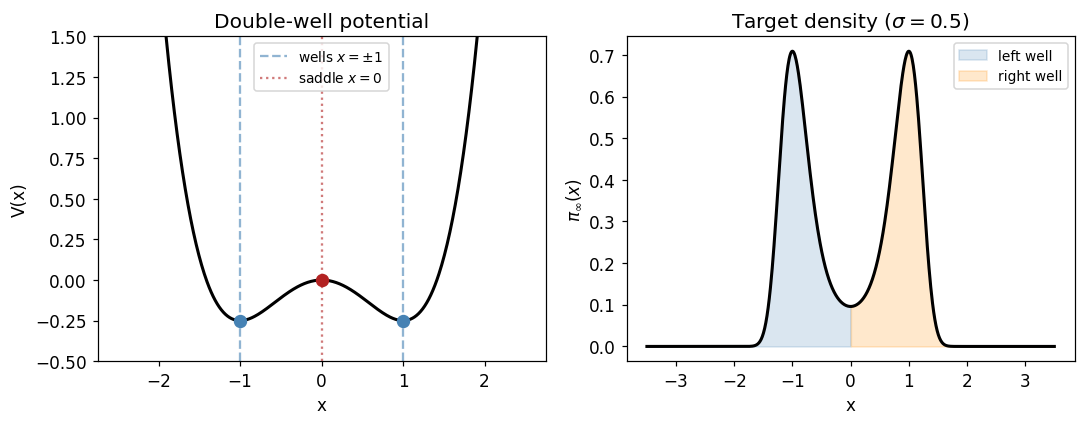

Saved to doublewell_output/doublewell_setup.{pdf,png}


In [10]:
# ── Figure 1: potential and target density ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
xs_p = np.linspace(-2.5, 2.5, 600)

ax = axes[0]
ax.plot(xs_p, V(xs_p), 'k-', lw=2)
ax.axvline(-1, color='steelblue', ls='--', alpha=0.6, label='wells $x=\\pm1$')
ax.axvline(+1, color='steelblue', ls='--', alpha=0.6)
ax.axvline( 0, color='firebrick', ls=':', alpha=0.6, label='saddle $x=0$')
ax.scatter([-1,1], [V(-1),V(1)], c='steelblue', zorder=5, s=60)
ax.scatter([0], [V(0)], c='firebrick', zorder=5, s=60)
ax.set(xlabel='x', ylabel='V(x)', title='Double-well potential')
ax.legend(fontsize=9); ax.set_ylim(-0.5, 1.5)

ax = axes[1]
xs_d = np.linspace(-3.5, 3.5, 700)
pi_v = target.density(xs_d)
ax.plot(xs_d, pi_v, 'k-', lw=2)
ax.fill_between(xs_d[xs_d<0], pi_v[xs_d<0], alpha=0.2, color='steelblue', label='left well')
ax.fill_between(xs_d[xs_d>0], pi_v[xs_d>0], alpha=0.2, color='darkorange', label='right well')
ax.set(xlabel='x', ylabel='$\\pi_\\infty(x)$', title=f'Target density ($\\sigma={SIGMA}$)')
ax.legend(fontsize=9)

plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(OUT / f'doublewell_setup.{ext}', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved to {OUT}/doublewell_setup.{{pdf,png}}")

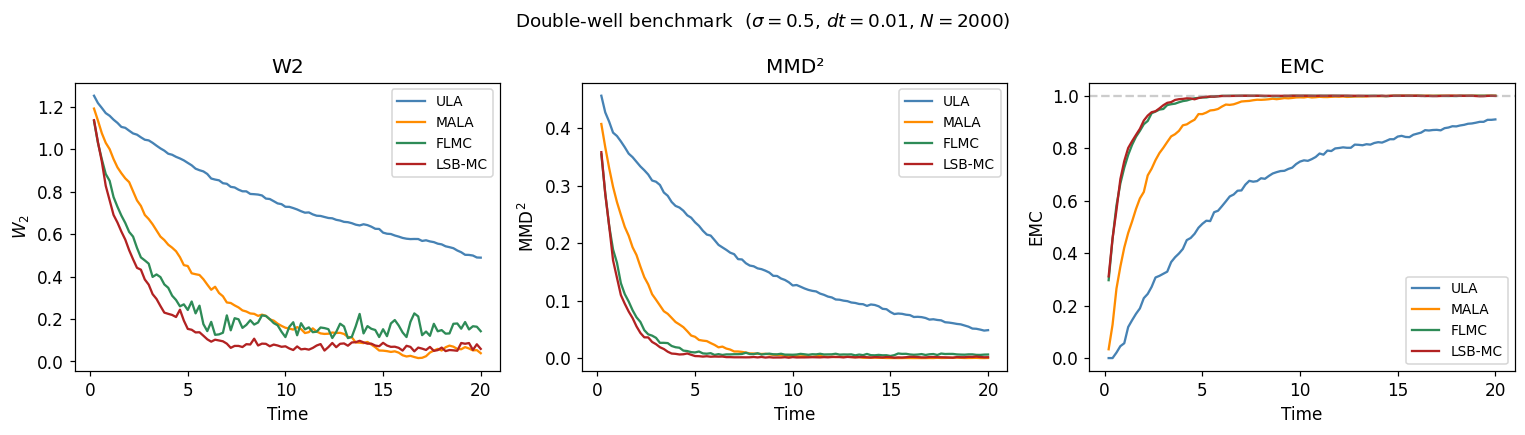

Saved to doublewell_output/doublewell_metrics.{pdf,png}


In [11]:
# ── Figure 2: metric curves ─────────────────────────────────────────
COLORS  = {'ULA':'steelblue','MALA':'darkorange','FLMC':'seagreen','LSB-MC':'firebrick'}
METHODS = ['ULA','MALA','FLMC','LSB-MC']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for m in METHODS:
    t, w2, mmd, em, ex2, _ = results[m]
    axes[0].plot(t, w2,  color=COLORS[m], lw=1.5, label=m)
    axes[1].plot(t, mmd, color=COLORS[m], lw=1.5, label=m)
    axes[2].plot(t, em,  color=COLORS[m], lw=1.5, label=m)

axes[0].set(xlabel='Time', ylabel='$W_2$',     title='W2')
axes[1].set(xlabel='Time', ylabel='MMD$^2$',   title='MMD²')
axes[2].set(xlabel='Time', ylabel='EMC',       title='EMC')
axes[2].axhline(1.0, color='gray', ls='--', alpha=0.4)
for ax in axes: ax.legend(fontsize=9)

plt.suptitle(f'Double-well benchmark  ($\\sigma={SIGMA}$, $dt={DT}$, $N={N_PART}$)', fontsize=12)
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(OUT / f'doublewell_metrics.{ext}', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved to {OUT}/doublewell_metrics.{{pdf,png}}")

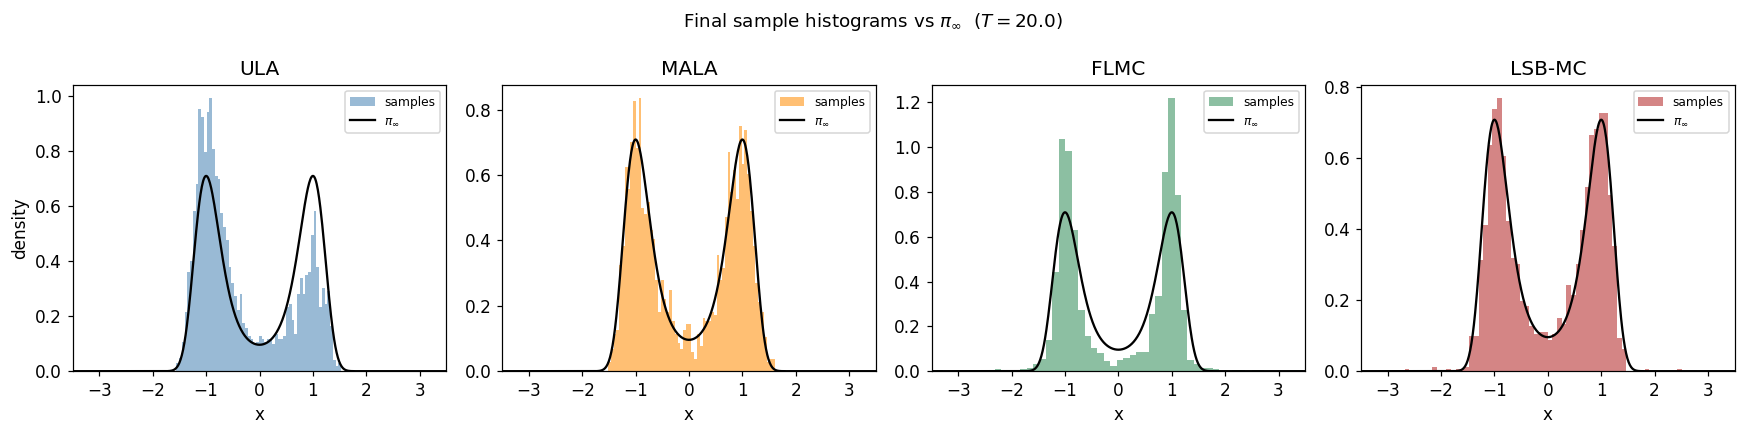

Saved to doublewell_output/doublewell_final_density.{pdf,png}


In [12]:
# ── Figure 3: final sample histograms ──────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
xs_d = np.linspace(-3.5, 3.5, 600)
pi_v = target.density(xs_d)

for ax, m in zip(axes, METHODS):
    _, _, _, _, _, x_fin = results[m]
    ax.hist(x_fin, bins=60, density=True, alpha=0.55, color=COLORS[m], label='samples')
    ax.plot(xs_d, pi_v, 'k-', lw=1.5, label='$\\pi_\\infty$')
    ax.set(title=m, xlabel='x', xlim=(-3.5, 3.5))
    ax.legend(fontsize=8)

axes[0].set_ylabel('density')
plt.suptitle(f'Final sample histograms vs $\\pi_\\infty$  ($T={T_TOTAL}$)', fontsize=12)
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(OUT / f'doublewell_final_density.{ext}', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved to {OUT}/doublewell_final_density.{{pdf,png}}")

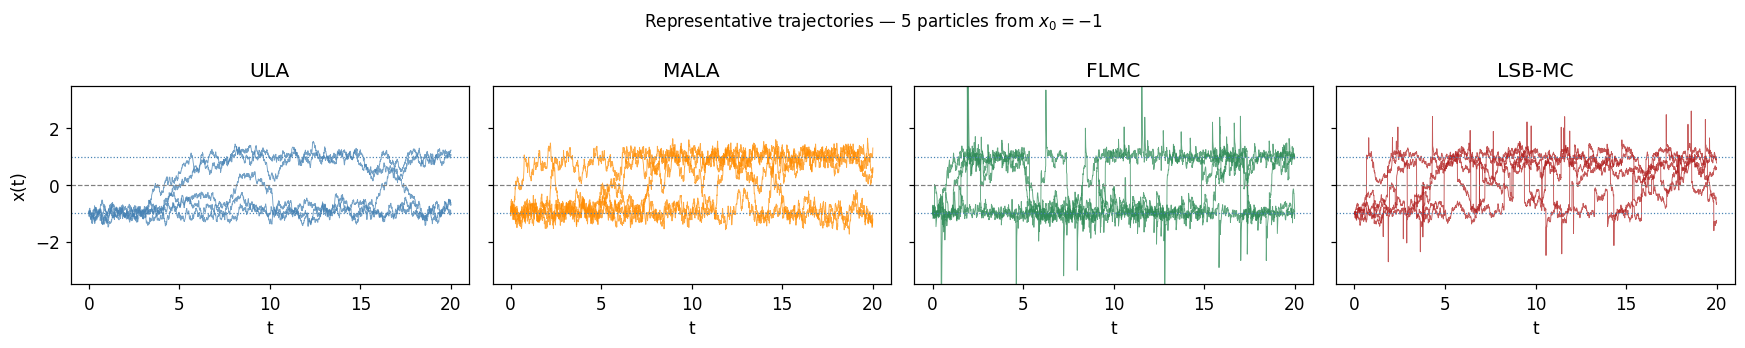

Saved to doublewell_output/doublewell_trajectories.{pdf,png}


In [13]:
# ── Figure 4: representative trajectories ──────────────────────────
N_TRAJ = 5
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
t_arr = np.arange(N_STEPS + 1) * DT

step_fns_traj = {
    'ULA':    lambda x, r: step_ula(x, DT, SIGMA, r),
    'MALA':   lambda x, r: step_mala(x, DT, SIGMA, r)[0],
    'FLMC':   lambda x, r: step_fla(x, DT, SIGMA, ALPHA_FLMC, r),
    'LSB-MC': lambda x, r: step_lsbmc(x, DT, SIGMA, LAM, r),
}

for ax, m in zip(axes, METHODS):
    rng_t = np.random.default_rng(GLOBAL_SEED + 300 + METHODS.index(m))
    x = np.full(N_TRAJ, -1.0)
    track = [x.copy()]
    fn = step_fns_traj[m]
    for _ in range(N_STEPS):
        x = fn(x, rng_t)
        track.append(x.copy())
    track = np.array(track)  # (N_STEPS+1, N_TRAJ)
    for j in range(N_TRAJ):
        ax.plot(t_arr, track[:, j], lw=0.6, alpha=0.75, color=COLORS[m])
    ax.axhline(0,  color='gray',      ls='--', lw=0.8)
    ax.axhline(-1, color='steelblue', ls=':', lw=0.8)
    ax.axhline(+1, color='steelblue', ls=':', lw=0.8)
    ax.set(title=m, xlabel='t', ylim=(-3.5, 3.5))

axes[0].set_ylabel('x(t)')
plt.suptitle(f'Representative trajectories — 5 particles from $x_0=-1$', fontsize=11)
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(OUT / f'doublewell_trajectories.{ext}', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved to {OUT}/doublewell_trajectories.{{pdf,png}}")

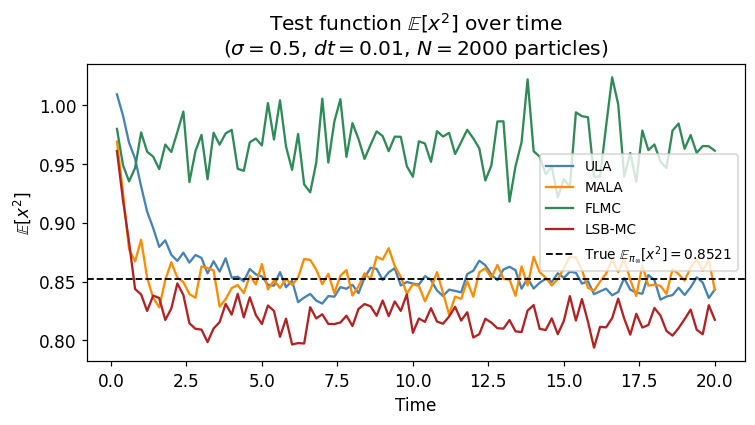

Saved to doublewell_output/doublewell_ex2.{pdf,png}
True E[x^2] = 0.852136
  ULA      final E[x^2] = 0.843151  (error -0.008985)
  MALA     final E[x^2] = 0.843047  (error -0.009089)
  FLMC     final E[x^2] = 0.961197  (error +0.109061)
  LSB-MC   final E[x^2] = 0.817607  (error -0.034529)


In [14]:
# ── Figure 5: E[x^2] as a test function ────────────────────────────
# The true value E_pi[x^2] = int x^2 pi_inf(x) dx is computed numerically
# from the TargetSampler grid and shown as a dashed reference line.

fig, ax = plt.subplots(figsize=(7, 4))

for m in METHODS:
    t, _, _, _, ex2, _ = results[m]
    ax.plot(t, ex2, color=COLORS[m], lw=1.5, label=m)

ax.axhline(_true_ex2, color='black', ls='--', lw=1.2,
           label=f'True $\\mathbb{{E}}_{{\\pi_\\infty}}[x^2] = {_true_ex2:.4f}$')

ax.set(xlabel='Time', ylabel='$\\mathbb{E}[x^2]$',
       title=f'Test function $\\mathbb{{E}}[x^2]$ over time\n'
             f'($\\sigma={SIGMA}$, $dt={DT}$, $N={N_PART}$ particles)')
ax.legend(fontsize=9)

plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(OUT / f'doublewell_ex2.{ext}', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved to {OUT}/doublewell_ex2.{{pdf,png}}")
print(f"True E[x^2] = {_true_ex2:.6f}")
for m in METHODS:
    final_ex2 = results[m][4][-1]
    print(f"  {m:8s} final E[x^2] = {final_ex2:.6f}  (error {final_ex2 - _true_ex2:+.6f})")